In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
raw_data_full = pd.read_csv("../data/crawled_autos.csv")
raw_data_full.head(10)

,brand,fuelType,gearbox,kilometer,model,powerPS,price,seller,url,vehicleType,yearOfRegistration
0,Peugeot,Gasoline,Manual,122566.0,2008,60 kW (82 hp),7450,Dealer,https://www.autoscout24.com/offers/peugeot-200...,SUV/Off-Road/Pick-Up,02/2017
1,Volkswagen,Gasoline,Automatic,10.0,T-Cross,110 kW (150 hp),30995,Dealer,https://www.autoscout24.com/offers/volkswagen-...,SUV/Off-Road/Pick-Up,02/2026
2,Toyota,Electric/Gasoline,Automatic,77984.0,C-HR,72 kW (98 hp),18900,Dealer,https://www.autoscout24.com/offers/toyota-c-hr...,SUV/Off-Road/Pick-Up,05/2020
3,Subaru,Gasoline,Automatic,114483.0,Levorg,125 kW (170 hp),15600,Dealer,https://www.autoscout24.com/offers/subaru-levo...,Station Wagon,07/2016
4,Skoda,Gasoline,Manual,27682.0,Kamiq,110 kW (150 hp),20900,Dealer,https://www.autoscout24.com/offers/skoda-kamiq...,SUV/Off-Road/Pick-Up,03/2023
5,Land,Diesel,Manual,79946.0,Rover Discovery Sport,110 kW (150 hp),13500,Dealer,https://www.autoscout24.com/offers/land-rover-...,SUV/Off-Road/Pick-Up,11/2016
6,Volkswagen,Gasoline,Manual,29532.0,Polo,70 kW (95 hp),15025,Dealer,https://www.autoscout24.com/offers/volkswagen-...,Sedan,10/2023
7,Toyota,Diesel,Automatic,53951.0,Proace City,96 kW (131 hp),27490,Dealer,https://www.autoscout24.com/offers/toyota-proa...,Van,04/2024
8,Peugeot,Gasoline,Manual,113455.0,3008,96 kW (131 hp),11990,Dealer,https://www.autoscout24.com/offers/peugeot-300...,SUV/Off-Road/Pick-Up,03/2017
9,Renault,LPG,Manual,1.0,Clio,74 kW (101 hp),19490,Dealer,https://www.autoscout24.com/offers/renault-cli...,Compact,03/2025


In [49]:
# Transformations
cols_to_lower = ["brand", "fuelType", "gearbox", "vehicleType"]
for col in cols_to_lower:
    raw_data_full[col] = raw_data_full[col].astype("string").str.strip().str.lower()

# Extract horsepower from patterns like "60 kW (82 hp)"
power_as_text = raw_data_full["powerPS"].astype("string")
hp_in_parentheses = power_as_text.str.extract(r"\((\d+)\s*hp\)", expand=False)
fallback_digits = power_as_text.str.extract(r"(\d+)", expand=False)
raw_data_full["powerPS"] = pd.to_numeric(hp_in_parentheses.fillna(fallback_digits), errors="coerce").astype("Int64")
raw_data_full["yearOfRegistration"] = (
    raw_data_full["yearOfRegistration"]
    .astype("string")
    .str.split('/')
    .str[1]
)
raw_data_full["yearOfRegistration"] = pd.to_numeric(raw_data_full["yearOfRegistration"], errors="coerce").astype("Int64")

raw_data_full[["brand", "fuelType", "gearbox", "vehicleType", "powerPS", "yearOfRegistration"]].head(10)

,brand,fuelType,gearbox,vehicleType,powerPS,yearOfRegistration
0,peugeot,gasoline,manual,suv/off-road/pick-up,82,2017
1,volkswagen,gasoline,automatic,suv/off-road/pick-up,150,2026
2,toyota,electric/gasoline,automatic,suv/off-road/pick-up,98,2020
3,subaru,gasoline,automatic,station wagon,170,2016
4,skoda,gasoline,manual,suv/off-road/pick-up,150,2023
5,land,diesel,manual,suv/off-road/pick-up,150,2016
6,volkswagen,gasoline,manual,sedan,95,2023
7,toyota,diesel,automatic,van,131,2024
8,peugeot,gasoline,manual,suv/off-road/pick-up,131,2017
9,renault,lpg,manual,compact,101,2025


In [50]:
# list all columns
print(raw_data_full.columns.values)

['brand' 'fuelType' 'gearbox' 'kilometer' 'model' 'powerPS' 'price'
 'seller' 'url' 'vehicleType' 'yearOfRegistration']


In [51]:
# select only the columns of interest
columns_of_interest = ['seller', 'vehicleType', 'yearOfRegistration', 'gearbox', 'powerPS', 'kilometer', 'fuelType', 'brand', 'price']
raw_data = raw_data_full[columns_of_interest]
raw_data.head(10)

,seller,vehicleType,yearOfRegistration,gearbox,powerPS,kilometer,fuelType,brand,price
0,Dealer,suv/off-road/pick-up,2017,manual,82,122566.0,gasoline,peugeot,7450
1,Dealer,suv/off-road/pick-up,2026,automatic,150,10.0,gasoline,volkswagen,30995
2,Dealer,suv/off-road/pick-up,2020,automatic,98,77984.0,electric/gasoline,toyota,18900
3,Dealer,station wagon,2016,automatic,170,114483.0,gasoline,subaru,15600
4,Dealer,suv/off-road/pick-up,2023,manual,150,27682.0,gasoline,skoda,20900
5,Dealer,suv/off-road/pick-up,2016,manual,150,79946.0,diesel,land,13500
6,Dealer,sedan,2023,manual,95,29532.0,gasoline,volkswagen,15025
7,Dealer,van,2024,automatic,131,53951.0,diesel,toyota,27490
8,Dealer,suv/off-road/pick-up,2017,manual,131,113455.0,gasoline,peugeot,11990
9,Dealer,compact,2025,manual,101,1.0,lpg,renault,19490


In [52]:
print(f"Shape of the dataset: {raw_data.shape}")
print(raw_data.info())

Shape of the dataset: (2507, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2507 entries, 0 to 2506
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   seller              2507 non-null   object 
 1   vehicleType         2507 non-null   string 
 2   yearOfRegistration  2438 non-null   Int64  
 3   gearbox             2503 non-null   string 
 4   powerPS             2500 non-null   Int64  
 5   kilometer           2486 non-null   float64
 6   fuelType            2505 non-null   string 
 7   brand               2507 non-null   string 
 8   price               2507 non-null   int64  
dtypes: Int64(2), float64(1), int64(1), object(1), string(4)
memory usage: 181.3+ KB
None


In [53]:
# count categorical cols, numerical cols and date cols
categorical_cols = raw_data.select_dtypes(exclude="number").columns
numerical_cols = raw_data.select_dtypes(include="number").columns
print("Categorical columns:", len(categorical_cols))
print("Numerical columns:", len(numerical_cols))
missing_values = raw_data.isnull().sum()
print("Total missing values in the dataset:", missing_values.sum())



Categorical columns: 5
Numerical columns: 4
Total missing values in the dataset: 103


In [54]:
numerical_cols_ = raw_data[["powerPS", "yearOfRegistration", "kilometer"]]
for col in numerical_cols_:
    print(f"Summary statistics for {col}:")
    print(raw_data[col].describe())
    print("\n")

Summary statistics for powerPS:
count        2500.0
mean         180.25
std      108.933582
min             8.0
25%           116.0
50%           150.0
75%           204.0
max           911.0
Name: powerPS, dtype: Float64


Summary statistics for yearOfRegistration:
count         2438.0
mean     2019.703856
std           5.6139
min           1932.0
25%           2018.0
50%           2021.0
75%           2023.0
max           2026.0
Name: yearOfRegistration, dtype: Float64


Summary statistics for kilometer:
count      2486.000000
mean      77469.718021
std       67824.184187
min           0.000000
25%       24925.000000
50%       63778.000000
75%      112194.250000
max      999999.000000
Name: kilometer, dtype: float64




In [55]:
# exploring price col
print("Price column info:")
print(raw_data["price"].describe())

Price column info:
count      2507.00000
mean      28444.04268
std       33461.21015
min         770.00000
25%       12990.00000
50%       20990.00000
75%       32900.00000
max      693403.00000
Name: price, dtype: float64


In [56]:
categorical_cols_ = raw_data.select_dtypes(exclude="number")
for col in categorical_cols_:
    if col == "name": continue
    print(f"\nCategories values in {col}:\n{raw_data[col].value_counts()}")
    print("\npercentage of each category:")
    print((raw_data[col].value_counts() * 100 / len(raw_data)).round(2))


Categories values in seller:
seller
Dealer    2507
Name: count, dtype: int64

percentage of each category:
seller
Dealer    100.0
Name: count, dtype: float64

Categories values in vehicleType:
vehicleType
suv/off-road/pick-up    1083
sedan                    532
compact                  306
station wagon            246
van                      147
convertible               75
coupe                     72
other                     46
Name: count, dtype: Int64

percentage of each category:
vehicleType
suv/off-road/pick-up     43.2
sedan                   21.22
compact                 12.21
station wagon            9.81
van                      5.86
convertible              2.99
coupe                    2.87
other                    1.83
Name: count, dtype: Float64

Categories values in gearbox:
gearbox
automatic         1662
manual             809
semi-automatic      32
Name: count, dtype: Int64

percentage of each category:
gearbox
automatic         66.29
manual            32.27
semi-a

In [71]:
# defining the threshold for the price tiers
price_thresholds = [0, 15000, 35000, float("inf")]
price_labels = ["budget", "mid-range", "luxury"]
# creating a new column for price tiers
raw_data["price_tier"] = pd.cut(raw_data["price"], bins=price_thresholds, labels=price_labels)
print(raw_data["price_tier"].value_counts())
print((raw_data["price_tier"].value_counts()/len(raw_data["price_tier"]) * 100).round(2), "%")
# print(raw_data_no_outliers[["price", "price_tier"]].head())

price_tier
mid-range    1188
budget        792
luxury        527
Name: count, dtype: int64
price_tier
mid-range    47.39
budget       31.59
luxury       21.02
Name: count, dtype: float64 %


/tmp/ipykernel_260192/2278106155.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_data["price_tier"] = pd.cut(raw_data["price"], bins=price_thresholds, labels=price_labels)


In [72]:
# checking for missing values
missing_values = raw_data.isnull().sum()

print("Total missing values in the dataset:", missing_values.sum())
print("Missing values in each column:")
print(f"{missing_values[missing_values > 0]}")
print(f"{(missing_values[missing_values > 0] * 100 / len(raw_data)).round(2)}")

Total missing values in the dataset: 103
Missing values in each column:
yearOfRegistration    69
gearbox                4
powerPS                7
kilometer             21
fuelType               2
dtype: int64
yearOfRegistration    2.75
gearbox               0.16
powerPS               0.28
kilometer             0.84
fuelType              0.08
dtype: float64


In [73]:
# checking for full-duplicates rows
duplicate_rows = raw_data[raw_data.duplicated()]
print("Number of duplicate rows:", duplicate_rows.shape[0])


Number of duplicate rows: 18


In [74]:
print(raw_data["yearOfRegistration"].describe())
print(raw_data["yearOfRegistration"].skew())

count         2438.0
mean     2019.703856
std           5.6139
min           1932.0
25%           2018.0
50%           2021.0
75%           2023.0
max           2026.0
Name: yearOfRegistration, dtype: Float64
-3.150781771442697


In [75]:
print(raw_data["powerPS"].describe())

count        2500.0
mean         180.25
std      108.933582
min             8.0
25%           116.0
50%           150.0
75%           204.0
max           911.0
Name: powerPS, dtype: Float64


In [76]:
# Data Validity Checks
print("Check for invalid powerPS values (<= 0) or (>= 5000):")
print(raw_data[raw_data['powerPS']<=0]["powerPS"].count())
print(raw_data[raw_data['powerPS']>=5000]["powerPS"].count())
print(f"Total invalid powerPS values: {(raw_data[raw_data['powerPS']<=0]['powerPS'].count() + raw_data[raw_data['powerPS']>=5000]['powerPS'].count())}")
print(f"percentage of invalid powerPS values: {((raw_data[raw_data['powerPS']<=0]['powerPS'].count() + raw_data[raw_data['powerPS']>=5000]['powerPS'].count()) * 100 / len(raw_data)).round(2)}% ")

print("Check for invalid kilometer values (< 0) or (> 300000):")
print(raw_data[raw_data['kilometer']<0]["kilometer"].count())
print(raw_data[raw_data['kilometer']>300000]["kilometer"].count())
print(f"Total invalid kilometer values: {(raw_data[raw_data['kilometer']<0]['kilometer'].count() + raw_data[raw_data['kilometer']>300000]['kilometer'].count())}")
print(f"percentage of invalid kilometer values: {((raw_data[raw_data['kilometer']<0]['kilometer'].count() + raw_data[raw_data['kilometer']>300000]['kilometer'].count()) * 100 / len(raw_data)).round(2)}% ")

print("Check for invalid yearOfRegistration values (< 1900):")
print(raw_data[raw_data['yearOfRegistration']<1900]["yearOfRegistration"].count())
print(f"Total invalid yearOfRegistration values: {raw_data[raw_data['yearOfRegistration']<1900]['yearOfRegistration'].count()}")
print("Check for invalid yearOfRegistration values (> 2023):")
print(raw_data[raw_data['yearOfRegistration']>2023]["yearOfRegistration"].count())
print(f"Total invalid yearOfRegistration values: {raw_data[raw_data['yearOfRegistration']>2023]['yearOfRegistration'].count()+raw_data[raw_data['yearOfRegistration']<1900]['yearOfRegistration'].count()}")
print(f"percentage of invalid yearOfRegistration values: {((raw_data[raw_data['yearOfRegistration']>2023]['yearOfRegistration'].count()+raw_data[raw_data['yearOfRegistration']<1900]['yearOfRegistration'].count()) * 100 / len(raw_data)).round(2)}% ")


Check for invalid powerPS values (<= 0) or (>= 5000):
0
0
Total invalid powerPS values: 0
percentage of invalid powerPS values: 0.0% 
Check for invalid kilometer values (< 0) or (> 300000):
0
13
Total invalid kilometer values: 13
percentage of invalid kilometer values: 0.52% 
Check for invalid yearOfRegistration values (< 1900):
0
Total invalid yearOfRegistration values: 0
Check for invalid yearOfRegistration values (> 2023):
555
Total invalid yearOfRegistration values: 555
percentage of invalid yearOfRegistration values: 22.14% 


In [77]:
print("Check for invalid price values (< 0):")
print(raw_data[raw_data['price']<0]["price"].count())
print(f"Total invalid price values: {raw_data[raw_data['price']<0]['price'].count()}")
print(f"percentage of invalid price values: {((raw_data[raw_data['price']<0]['price'].count()) * 100 / len(raw_data)).round(2)}% ")


Check for invalid price values (< 0):
0
Total invalid price values: 0
percentage of invalid price values: 0.0% 


In [78]:
# removing outliers from price col using IQR method
print(raw_data["price"].describe())
Q1 = raw_data["price"].quantile(0.25)
Q3 = raw_data["price"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
raw_data_outliers = raw_data[(raw_data["price"] < lower_bound) | (raw_data["price"] > upper_bound)]
raw_data_no_outliers = raw_data[(raw_data["price"] >= lower_bound) & (raw_data["price"] <= upper_bound)]
print("Number of outliers in price column:", raw_data_outliers.shape[0])
print("Percentage of outliers in price column:", (raw_data_outliers.shape[0] / len(raw_data)) * 100)


count      2507.00000
mean      28444.04268
std       33461.21015
min         770.00000
25%       12990.00000
50%       20990.00000
75%       32900.00000
max      693403.00000
Name: price, dtype: float64
Number of outliers in price column: 166
Percentage of outliers in price column: 6.6214599122457125


In [79]:
# Outliers in kilometer col using IQR method
print(raw_data["kilometer"].describe())
Q1_km = raw_data["kilometer"].quantile(0.25)
Q3_km = raw_data["kilometer"].quantile(0.75)
IQR_km = Q3_km - Q1_km
lower_bound_km = Q1_km - 1.5 * IQR_km
upper_bound_km = Q3_km + 1.5 * IQR_km
raw_data_km_outliers = raw_data[(raw_data["kilometer"] < lower_bound_km) | (raw_data["kilometer"] > upper_bound_km)]
raw_data_km_no_outliers = raw_data[(raw_data["kilometer"] >= lower_bound_km) & (raw_data["kilometer"] <= upper_bound_km)]
print("Number of outliers in kilometer column:", raw_data_km_outliers.shape[0])
print("Percentage of outliers in kilometer column:", (raw_data_km_outliers.shape[0] / len(raw_data)) * 100) 

count      2486.000000
mean      77469.718021
std       67824.184187
min           0.000000
25%       24925.000000
50%       63778.000000
75%      112194.250000
max      999999.000000
Name: kilometer, dtype: float64
Number of outliers in kilometer column: 54
Percentage of outliers in kilometer column: 2.1539688871160747


In [80]:
# Skewness
print("Skewness of price column:", raw_data["price"].skew())
print("Skewness of kilometer column:", raw_data["kilometer"].skew())
print("Skewness of power column:", raw_data["powerPS"].skew())
print("Skewness of registration year column:", raw_data["yearOfRegistration"].skew())

Skewness of price column: 7.396715233196219
Skewness of kilometer column: 1.997188084483022
Skewness of power column: 2.149395948074528
Skewness of registration year column: -3.150781771442697


In [81]:
# Checking Consistency - Schema & Data Types
print("Data Types of Each Column:")
print(raw_data.dtypes)


Data Types of Each Column:
seller                        object
vehicleType           string[python]
yearOfRegistration             Int64
gearbox               string[python]
powerPS                        Int64
kilometer                    float64
fuelType              string[python]
brand                 string[python]
price                          int64
price_tier                  category
dtype: object


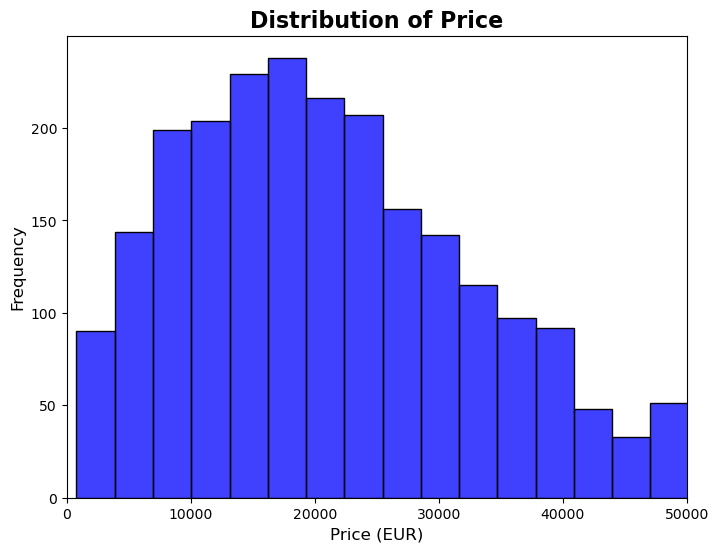

In [82]:
# visualizing the distribution of price tiers
plt.figure(figsize=(8, 6))
sns.histplot(raw_data_no_outliers["price"], bins=20, color="blue")
plt.title("Distribution of Price", fontsize=16, fontweight='bold')
plt.xlabel("Price (EUR)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xlim(0, 50000)
plt.savefig("../reports/price_distribution.png")
plt.show()

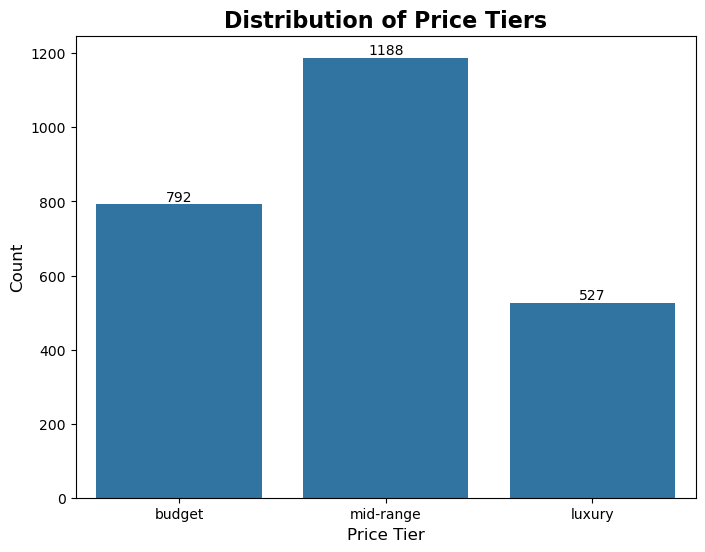

In [96]:
from collections import Counter
plt.figure(figsize=(8, 6))
sns.countplot(x="price_tier", data=raw_data)
plt.title("Distribution of Price Tiers", fontsize=16, fontweight='bold')
plt.xlabel("Price Tier", fontsize=12)
plt.ylabel("Count", fontsize=12)

c = Counter(raw_data["price_tier"].values)

plt.text(0, c['budget'], str(c['budget']), ha='center', va='bottom')
plt.text(1, c['mid-range'], str(c['mid-range']), ha='center', va='bottom')
plt.text(2, c['luxury'], str(c['luxury']), ha='center', va='bottom')

plt.savefig("../reports/price_tier_distribution.png")
plt.show()

In [84]:
raw_data.head()

,seller,vehicleType,yearOfRegistration,gearbox,powerPS,kilometer,fuelType,brand,price,price_tier
0,Dealer,suv/off-road/pick-up,2017,manual,82,122566.0,gasoline,peugeot,7450,budget
1,Dealer,suv/off-road/pick-up,2026,automatic,150,10.0,gasoline,volkswagen,30995,mid-range
2,Dealer,suv/off-road/pick-up,2020,automatic,98,77984.0,electric/gasoline,toyota,18900,mid-range
3,Dealer,station wagon,2016,automatic,170,114483.0,gasoline,subaru,15600,mid-range
4,Dealer,suv/off-road/pick-up,2023,manual,150,27682.0,gasoline,skoda,20900,mid-range


In [87]:
raw_data.to_csv("../data/crawled_dataset_features.csv", index=False)